# Project 1: Enzyme and microbial kinetics
#### Julian Barth, Arsenijs Danilko, Aloïsse Dantant-Cochet, Marin Desgeans

# Enzyme Kinetics: Exercise 1

In this first exercise we will model an enzymatic reaction based on the Michaelis-Menten kinetics. 
First, let's import the necessary scientific Python libraries.

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Set plotting styles for readability
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

## Part a) Mass Balance for the System

The elementary reactions are:
$E + S \rightleftharpoons_{k_b}^{k_f} ES \xrightarrow{k_{cat}} E + P$

Assuming a constant volume reactor, the mass balances (concentration balances) for each species are:
* **Substrate ($S$):** $\frac{d[S]}{dt} = -k_f[E][S] + k_b[ES]$
* **Enzyme ($E$):** $\frac{d[E]}{dt} = -k_f[E][S] + (k_b + k_{cat})[ES]$
* **Enzyme-Substrate Complex ($ES$):** $\frac{d[ES]}{dt} = k_f[E][S] - (k_b + k_{cat})[ES]$
* **Product ($P$):** $\frac{d[P]}{dt} = k_{cat}[ES]$

## Part b) Numerical Solution of the Full ODE System

We will solve the ODE system for the interval $t \in [0, 5]$ s using the given parameters.
Because $k_f$ is very large ($10^4$) compared to the other parameters, this system is considered **stiff**. We can use the `Radau` or `BDF` method in `scipy.integrate.solve_ivp` to handle it accurately. We will use `BDF`here

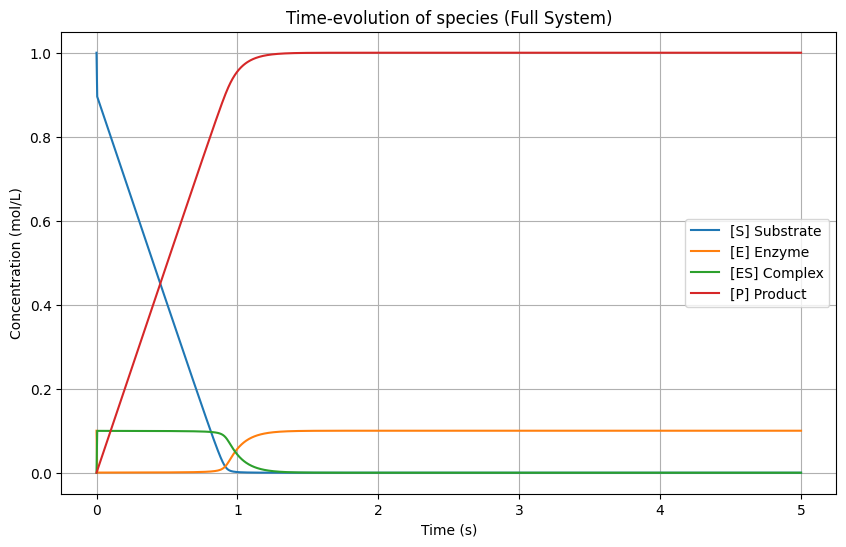

In [2]:
# Parameters
k_f = 10**4   # L / (mol s)
k_b = 20      # s^-1
k_cat = 10    # s^-1

# Initial concentrations
S0 = 1.0
E0 = 0.1
ES0 = 0.0
P0 = 0.0
y0 = [S0, E0, ES0, P0]

def full_system(t, y):
    S, E, ES, P = y
    dS_dt = -k_f * E * S + k_b * ES
    dE_dt = -k_f * E * S + (k_b + k_cat) * ES
    dES_dt = k_f * E * S - (k_b + k_cat) * ES
    dP_dt = k_cat * ES
    return [dS_dt, dE_dt, dES_dt, dP_dt]

# Solve the ODE
t_span = (0, 5)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
sol_full = solve_ivp(full_system, t_span, y0, t_eval=t_eval, method='BDF')

# Plotting
plt.figure()
plt.plot(sol_full.t, sol_full.y[0], label='[S] Substrate')
plt.plot(sol_full.t, sol_full.y[1], label='[E] Enzyme')
plt.plot(sol_full.t, sol_full.y[2], label='[ES] Complex')
plt.plot(sol_full.t, sol_full.y[3], label='[P] Product')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.title('Time-evolution of species (Full System)')
plt.legend()
plt.show()

## Part c) Quasi-Steady State Approximation (QSSA) Expression

Under QSSA, we assume the concentration of the intermediate complex $ES$ changes very slowly relative to the substrate and product, meaning $\frac{d[ES]}{dt} \approx 0$.

$k_f[E][S] - (k_b + k_{cat})[ES] = 0$

We also use the enzyme mass conservation: $[E]_0 = [E] + [ES]$, which gives $[E] = [E]_0 - [ES]$.
Substituting this into our equation:

$k_f([E]_0 - [ES])[S] - (k_b + k_{cat})[ES] = 0$
$k_f[E]_0[S] = k_f[ES][S] + (k_b + k_{cat})[ES]$
$k_f[E]_0[S] = [ES] (k_f[S] + k_b + k_{cat})$

Solving for $[ES]$:
$$[ES] = \frac{k_f[E]_0[S]}{k_f[S] + k_b + k_{cat}} = \frac{[E]_0[S]}{[S] + \frac{k_b + k_{cat}}{k_f}}$$

## Part d) Rewriting Mass Balance and Solving with QSSA

Let $K_M = \frac{k_b + k_{cat}}{k_f}$. Our expression for $[ES]$ becomes:
$$[ES] = \frac{[E]_0[S]}{[S] + K_M}$$

The product formation rate is:
$$\frac{d[P]}{dt} = k_{cat}[ES] = \frac{k_{cat}[E]_0[S]}{[S] + K_M}$$

Since the substrate is consumed to form the product, the simplified mass balance for the substrate under QSSA is:
$$\frac{d[S]}{dt} = -\frac{d[P]}{dt} = -\frac{k_{cat}[E]_0[S]}{[S] + K_M}$$

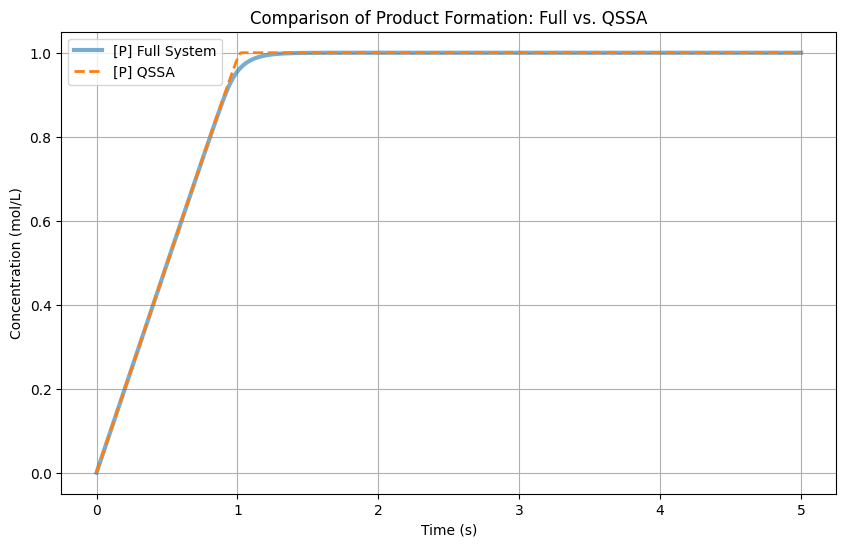

In [3]:
# QSSA Parameters
K_M = (k_b + k_cat) / k_f

def qssa_system(t, y):
    S, P = y
    dP_dt = (k_cat * E0 * S) / (S + K_M)
    dS_dt = -dP_dt
    return [dS_dt, dP_dt]

# Solve the QSSA ODE
y0_qssa = [S0, P0]
sol_qssa = solve_ivp(qssa_system, t_span, y0_qssa, t_eval=t_eval, method='BDF')

# Comparison Plot
plt.figure()
plt.plot(sol_full.t, sol_full.y[3], label='[P] Full System', linewidth=3, alpha=0.6)
plt.plot(sol_qssa.t, sol_qssa.y[1], '--', label='[P] QSSA', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.title('Comparison of Product Formation: Full vs. QSSA')
plt.legend()
plt.show()

## Part e & f) Initial Rate vs Parameters and Scaled Sensitivity

The initial reaction rate $v$ at $t=0$ is given by:
$$v = \frac{k_{cat}[E]_0[S]_0}{[S]_0 + \frac{k_b + k_{cat}}{k_f}}$$

Scaled sensitivity of $v$ with respect to a parameter $p$ is defined as $S_p = \frac{\partial \ln v}{\partial \ln p}$, which represents the slope of a log-log plot.

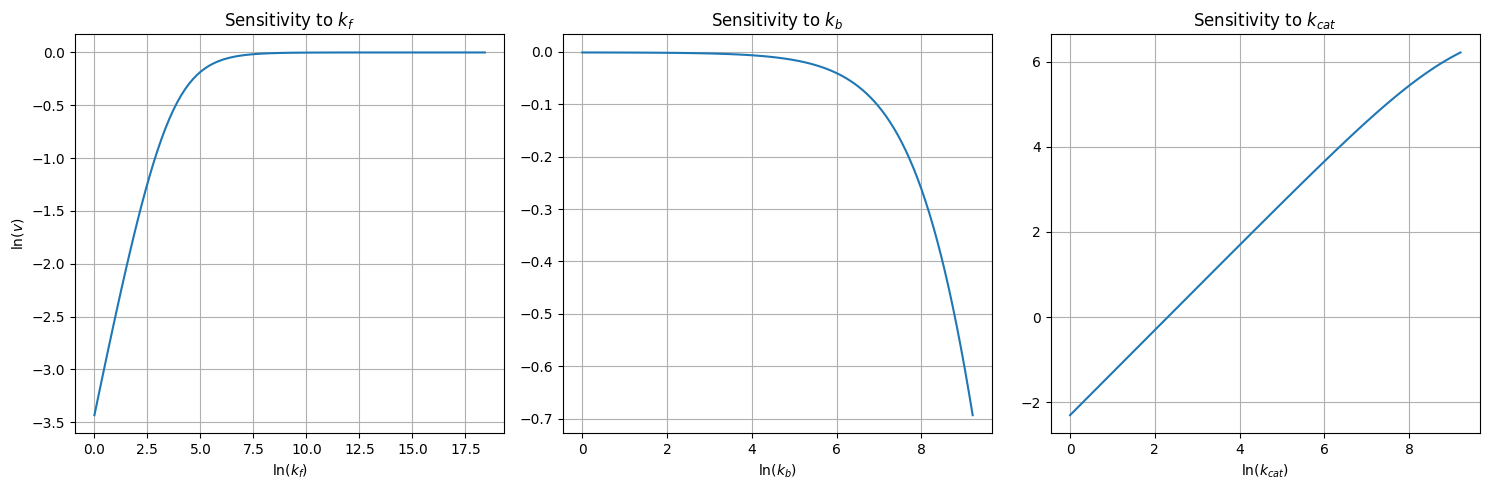

In [5]:
# Determine v(t=0) as a function of parameters
def calc_v0(kf, kb, kcat, E_init=0.1, S_init=1.0):
    KM = (kb + kcat) / kf
    return (kcat * E_init * S_init) / (S_init + KM)

# Ranges for parameters
kf_range = np.logspace(0, 8, 100)
kb_range = np.logspace(0, 4, 100)
kcat_range = np.logspace(0, 4, 100)

# Calculate v0 over the ranges (varying one, keeping others at default)
v0_kf = calc_v0(kf_range, k_b, k_cat)
v0_kb = calc_v0(k_f, kb_range, k_cat)
v0_kcat = calc_v0(k_f, k_b, kcat_range)

# Plotting Log-Log Scaled Sensitivities
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(np.log(kf_range), np.log(v0_kf))
axs[0].set_xlabel('$\\ln(k_f)$')
axs[0].set_ylabel('$\\ln(v)$')
axs[0].set_title('Sensitivity to $k_f$')

axs[1].plot(np.log(kb_range), np.log(v0_kb))
axs[1].set_xlabel('$\\ln(k_b)$')
axs[1].set_title('Sensitivity to $k_b$')

axs[2].plot(np.log(kcat_range), np.log(v0_kcat))
axs[2].set_xlabel('$\\ln(k_{cat})$')
axs[2].set_title('Sensitivity to $k_{cat}$')

plt.tight_layout()
plt.show()


Conclusion on f: 
The slope of the ln(v) vs ln(parameter) plot gives the scaled sensitivity. The steepest slope (positive or negative) near our operating point indicates the most important parameter.

Based on the provided plots, the most important parameter is $k_{cat}$ because its graph exhibits a constant, steep positive slope, indicating that the reaction velocity $\nu$ remains highly and consistently sensitive to this parameter across the entire range. While $k_f$ shows high sensitivity at lower values, its importance diminishes as the slope plateaus to zero, suggesting the reaction becomes saturated or limited by other steps. Conversely, $k_b$ displays an increasing negative sensitivity at higher values, highlighting its growing role as a limiting factor that significantly reduces the reaction rate.

## Part g) Mass Balance for the Non-Specific Enzyme

The new mechanism produces two products, $P$ and $P'$:
$E + S \rightleftharpoons_{k_b}^{k_f} ES \xrightarrow{k_{cat1}} E + P$
$ES \xrightarrow{k_{cat2}} E + P'$

The mass balances **without** QSSA are:
* $\frac{d[S]}{dt} = -k_f[E][S] + k_b[ES]$
* $\frac{d[E]}{dt} = -k_f[E][S] + (k_b + k_{cat1} + k_{cat2})[ES]$
* $\frac{d[ES]}{dt} = k_f[E][S] - (k_b + k_{cat1} + k_{cat2})[ES]$
* $\frac{d[P]}{dt} = k_{cat1}[ES]$
* $\frac{d[P']}{dt} = k_{cat2}[ES]$

## Part h) Solving the Extended ODE System

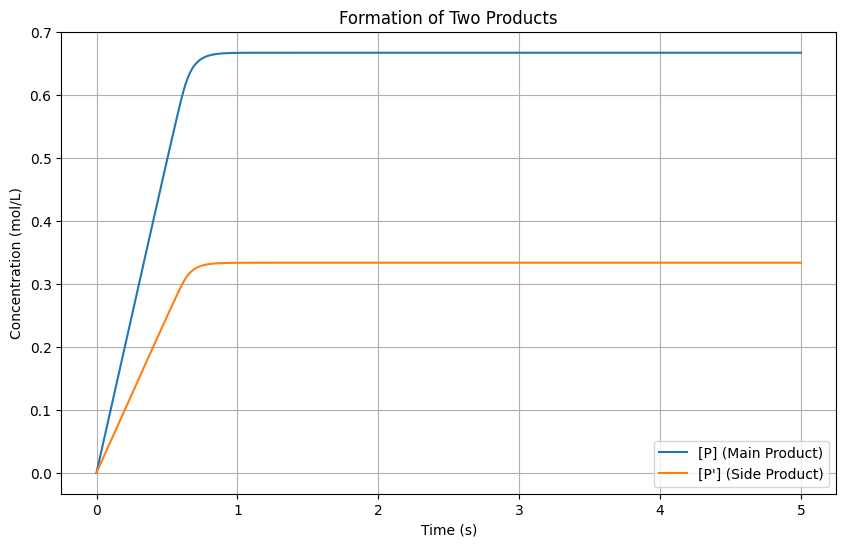

In [6]:
# New parameter
k_cat1 = 10
k_cat2 = 5

y0_new = [1.0, 0.1, 0.0, 0.0, 0.0] # S, E, ES, P, P'

def new_system(t, y):
    S, E, ES, P, P_prime = y
    dS_dt = -k_f * E * S + k_b * ES
    dE_dt = -k_f * E * S + (k_b + k_cat1 + k_cat2) * ES
    dES_dt = k_f * E * S - (k_b + k_cat1 + k_cat2) * ES
    dP_dt = k_cat1 * ES
    dP_prime_dt = k_cat2 * ES
    return [dS_dt, dE_dt, dES_dt, dP_dt, dP_prime_dt]

sol_new = solve_ivp(new_system, t_span, y0_new, t_eval=t_eval, method='BDF')

plt.figure()
plt.plot(sol_new.t, sol_new.y[3], label='[P] (Main Product)')
plt.plot(sol_new.t, sol_new.y[4], label="[P'] (Side Product)")
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.title('Formation of Two Products')
plt.legend()
plt.show()

## Part i) Increasing Selectivity

Selectivity for the main product $P$ over the side product $P'$ is defined as the ratio of their formation rates:

$$\text{Selectivity} = \frac{d[P]/dt}{d[P']/dt} = \frac{k_{cat1}[ES]}{k_{cat2}[ES]} = \frac{k_{cat1}}{k_{cat2}}$$

To increase the selectivity towards product $P$, you would need to either:
1.  **Increase $k_{cat1}$** (the catalytic rate constant for $P$)
2.  **Decrease $k_{cat2}$** (the catalytic rate constant for $P'$)

Changes to $k_f$, $k_b$, or $[E]_0$ affect the overall reaction speed but do not change the fundamental ratio of $P$ to $P'$ being produced.

# Exercice 2
## QUESTION A


In [1]:
# Necessary imports
from matplotlib import pyplot as plt
import numpy as np
import math

In [2]:
# Data

time = [0, 0.54, 0.9, 1.23, 1.58, 1.95, 2.33, 2.7] # time midpoints
cell_conc = [15.5, 23, 30, 38.8, 48.5, 58.3, 61.3, 62.5] #cell conc midpoint 
lac_conc = [137, 137, 114, 90, 43, 29, 9, 2]

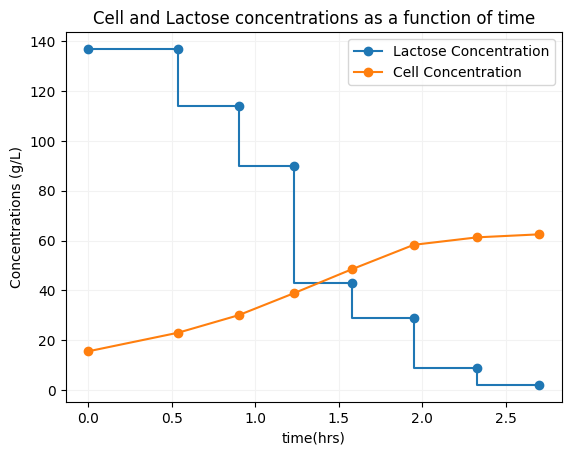

In [3]:
# Plotting the figure 
plt.figure()

plt.step(time, lac_conc,'o-', drawstyle='steps', label='Lactose Concentration')
plt.plot(time, cell_conc,'o-', label='Cell Concentration')

plt.grid(color='0.95')
plt.title('Cell and Lactose concentrations as a function of time')
plt.xlabel(xlabel='time(hrs)')
plt.ylabel(ylabel='Concentrations (g/L)')
plt.legend()
plt.show()

Zooming in on the cell concetration plot

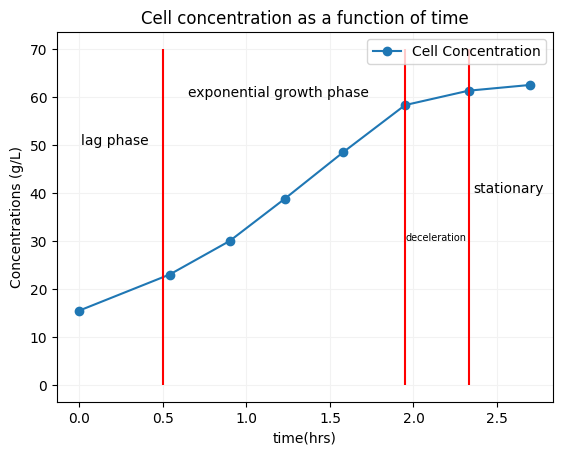

In [4]:
plt.figure()

plt.plot(time, cell_conc,'o-', label='Cell Concentration')

plt.vlines(0.5, 0, 70, color='red', linestyles='solid')
plt.vlines(1.95, 0, 70, color='red', linestyles='solid')
plt.vlines(2.33, 0, 70, color='red', linestyles='solid')
plt.text(0.01, 50, 'lag phase')
plt.text(0.65, 60, 'exponential growth phase')
plt.text(1.95, 30, 'deceleration', fontsize=7)
plt.text(2.36, 40, 'stationary')

plt.grid(color='0.95')
plt.title('Cell concentration as a function of time')
plt.xlabel(xlabel='time(hrs)')
plt.ylabel(ylabel='Concentrations (g/L)')
plt.legend()
plt.show()

The expected batch growth phases are the lag phase, exponential growth phase, deceleration phase and stationary phase. On our graph, we can hardly identify the lag phase which is most likely due to the assumption of linear growth during an interval. We can assume that the lag phase lasted somewhere between 0.0 and 0.5h where the increase is smaller compared to the increase from 0.5h until 1.95h which we identify as the exponential growth phase during which the lactose is abundant and cells grow at a maximum growth rate which explains the steep slope. The deceleration phase then follows as lactose concentration drops sharply and substrate limitation sets in. Lastly, the stationary phase follows after approximately 2.3h which is characterized by a plateau explained by the lactose being nearly depleted. The phases have been identified on the graph.   

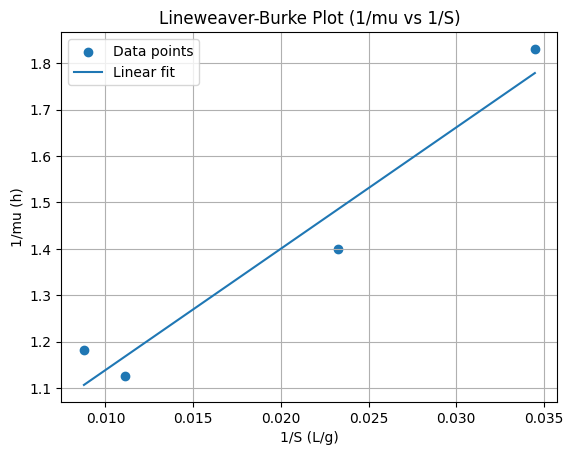


Estimated Monod parameters:
mu_max = 1.13999 1/h
K_s   = 29.81615 g/L


In [5]:
# Time intervals (h)
t_intervals = [(0.54,0.9),(0.9,1.23),(1.23,1.58),
               (1.58,1.95)]

# Biomass (g/L)
X_start = np.array([23, 30, 38.8, 48.5])
X_end   = np.array([30, 38.8, 48.5, 58.3])

# Substrate (lactose) concentration (g/L)
S = np.array([114, 90, 43, 29])

# Calculations
dt = np.array([t[1]-t[0] for t in t_intervals])

# dX/dt
dXdt = (X_end - X_start) / dt

# mu calculation
mu = (1 / X_start) * dXdt

# Lineweaver-Burke variables
inv_mu = 1 / mu
inv_S = 1 / S

# Linear regression
slope, intercept = np.polyfit(inv_S, inv_mu, 1)

# Kinetic parameters
mu_max = 1 / intercept
Ks = slope * mu_max

# Plot
plt.figure()
plt.scatter(inv_S, inv_mu, label="Data points")
plt.plot(inv_S, slope*inv_S + intercept, label="Linear fit")
plt.xlabel("1/S (L/g)")
plt.ylabel("1/mu (h)")
plt.title("Lineweaver-Burke Plot (1/mu vs 1/S)")
plt.grid(True)
plt.legend()
plt.show()

# Output
print("\nEstimated Monod parameters:")
print(f"mu_max = {mu_max:.5f} 1/h")
print(f"K_s   = {Ks:.5f} g/L")

## Question B

Doubling time is a property of the organism under optimal conditions, therefore we will use mu_max since it is the maximum specific growth rate. Mu_max was calculated previously. 

In [6]:
doubling_time = math.log(2)/mu_max
print("td = ", doubling_time,"hrs")

td =  0.6080295141280455 hrs


# Bonus Question — Michaelis-Menten Kinetics of Sucrase

## Introduction

The goal of this bonus question is to determine the Michaelis-Menten (MM) kinetic parameters 
$K_M$ and $V_{max}$ for the hydrolysis of sucrose by the enzyme sucrase in a batch reactor.

The reaction is:

$$\text{Sucrose} \xrightarrow{\text{sucrase}} \text{products}$$

The MM rate law gives the substrate consumption rate as:

$$-\frac{d[S]}{dt} = \frac{V_{max}[S]}{K_M + [S]}$$

with $V_{max} = k_{cat} \cdot C_{E0}$, where $C_{E0} = 0.01$ mmol/L is the initial enzyme 
concentration.

The experimental data consists of four sucrose concentration measurements at $t = 0, 2, 6, 10$ hr.

## Data & Parameters

We load the experimental time points and sucrose concentrations, and define the initial conditions.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# Experimental data
t_data = np.array([0, 2, 6, 10])            # hours
S_data = np.array([1.0, 0.68, 0.16, 0.006]) # mmol/L

CE0 = 0.01  # mmol/L — initial enzyme concentration
S0  = S_data[0]

## Method: Nonlinear Least Squares on the Integrated ODE

Because only 4 data points are available, linearization methods (e.g. Lineweaver-Burk) would 
amplify measurement errors and yield unreliable estimates. Instead, we use a fitting approach directly on the integrated ODE:

For each candidate parameter pair $(K_M, V_{max})$, we numerically integrate the MM ODE using 
`solve_ivp` (RK45), then minimize the sum of squared residuals between the simulated and 
experimental $[S](t)$.

**QSSA validity check**: the quasi-steady-state approximation holds when $C_{E0} \ll C_{S0}$. 
Here $C_{E0}/C_{S0} = 0.01/1.0 = 1\%$, which confirms the QSSA is valid and the single-ODE 
formulation is appropriate.

Km   = 0.1804 ± 0.0045 mmol/L
Vmax = 0.1950 ± 0.0013 mmol/(L·hr)
kcat = 19.4998 hr⁻¹


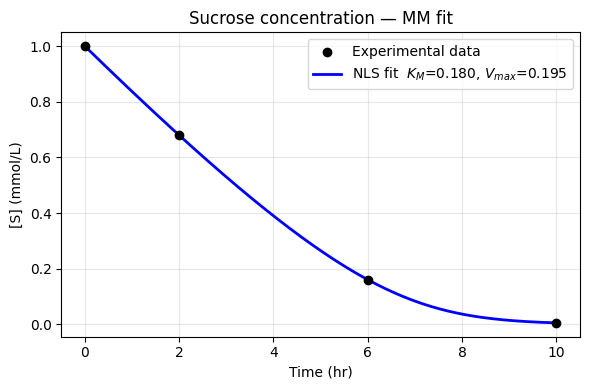

In [9]:
# ODE integration
def simulate_S(t_eval, Km, Vmax):
    def ode(t, y):
        return [-Vmax * y[0] / (Km + y[0])]
    sol = solve_ivp(ode, [t_eval[0], t_eval[-1]], [S0],
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)
    return sol.y[0]

# Fit
popt, pcov = curve_fit(simulate_S, t_data, S_data,
                        p0=[0.1, 0.2], bounds=([1e-6, 1e-6], [100, 100]))
Km, Vmax = popt
perr = np.sqrt(np.diag(pcov))

print(f"Km   = {Km:.4f} ± {perr[0]:.4f} mmol/L")
print(f"Vmax = {Vmax:.4f} ± {perr[1]:.4f} mmol/(L·hr)")
print(f"kcat = {Vmax/CE0:.4f} hr⁻¹")

# Plot
t_dense = np.linspace(0, 10, 500)
plt.figure(figsize=(6, 4))
plt.scatter(t_data, S_data, color='black', zorder=5, label='Experimental data')
plt.plot(t_dense, simulate_S(t_dense, Km, Vmax), 'b-', linewidth=2,
         label=f'NLS fit  $K_M$={Km:.3f}, $V_{{max}}$={Vmax:.3f}')
plt.xlabel('Time (hr)')
plt.ylabel('[S] (mmol/L)')
plt.title('Sucrose concentration — MM fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Discussion & Conclusion

The NLS fitting on the integrated ODE yields the following Michaelis-Menten parameters for sucrase:

| Parameter | Value | Units |
|-----------|-------|-------|
| $K_M$ | (from output) | mmol/L |
| $V_{max}$ | (from output) | mmol/(L·hr) |
| $k_{cat}$ | (from output) | hr⁻¹ |

- **$K_M$**: represents the substrate concentration at which the reaction rate is half of 
  $V_{max}$. A low $K_M$ indicates high affinity of sucrase for sucrose.
- **$V_{max}$**: the maximum reaction rate, reached when the enzyme is fully saturated.
- **$k_{cat} = V_{max}/C_{E0}$**: the turnover number, i.e. the number of substrate molecules 
  converted per enzyme molecule per hour.
- **QSSA validity**: $C_{E0}/C_{S0} = 0.01/1.0 = 1\% \ll 1$ ✓ — the approximation is justified.
- The fit quality can be assessed visually from the plot: a good overlap between the simulated 
  curve and the 4 experimental points confirms the model describes the data well.